# 10 — CNN Image Classification Project (CIFAR-10)
*End-to-end deep learning pipeline with data augmentation and a small UI demo.*

**What you'll do**
- Load CIFAR-10 and explore sample images
- Build train/val/test splits with data augmentations
- Train a CNN with PyTorch (cross-entropy, Adam)
- Evaluate with accuracy & confusion matrix; inspect misclassifications
- Wrap the trained model in a small Gradio UI for interactive predictions

This project mirrors a standard vision pipeline used in deep RL encoders.

## 0. Imports & Device

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split
import torchvision
import torchvision.transforms as T

from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report

from PIL import Image
import gradio as gr

plt.style.use("ggplot")

device = torch.device("mps" if torch.backends.mps.is_available() else "cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

/opt/miniconda3/envs/rlfs/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Using device: mps


## 1. Load CIFAR-10 & Define Transforms (with Augmentations)

We use:
- RandomCrop + padding → small translations / zoom
- RandomHorizontalFlip → left/right invariance
- ColorJitter + small Rotation → robustness to lighting and orientation
- Normalization with CIFAR-10 stats

In [2]:
DATA_ROOT = "./data"

# Data augmentations (training)
train_transform = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(p=0.5),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    T.RandomRotation(degrees=10),
    T.ToTensor(),
    T.Normalize(mean=(0.4914, 0.4822, 0.4465),
                std=(0.2023, 0.1994, 0.2010)),
])

# Deterministic transforms (validation / test / inference)
test_transform = T.Compose([
    T.ToTensor(),
    T.Normalize(mean=(0.4914, 0.4822, 0.4465),
                std=(0.2023, 0.1994, 0.2010)),
])

# For the UI we'll reuse this as inference pipeline
inference_transform = test_transform

# Download CIFAR-10
full_train = torchvision.datasets.CIFAR10(
    root=DATA_ROOT, train=True, download=True, transform=train_transform
)
test_ds = torchvision.datasets.CIFAR10(
    root=DATA_ROOT, train=False, download=True, transform=test_transform
)

class_names = full_train.classes
print("Classes:", class_names)
print("Train size:", len(full_train), "Test size:", len(test_ds))

Files already downloaded and verified
Files already downloaded and verified
Classes: ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
Train size: 50000 Test size: 10000


## 2. Train / Validation Split & DataLoaders

In [3]:
# Split train into (train, val)
train_size = int(0.9 * len(full_train))
val_size = len(full_train) - train_size
train_ds, val_ds = random_split(
    full_train, [train_size, val_size],
    generator=torch.Generator().manual_seed(42)
)

batch_size = 128

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_ds,   batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}, Val batches: {len(val_loader)}, Test batches: {len(test_loader)}")

Train batches: 352, Val batches: 40, Test batches: 79


## 3. Utility: Unnormalize & Visualize Samples / Augmentations

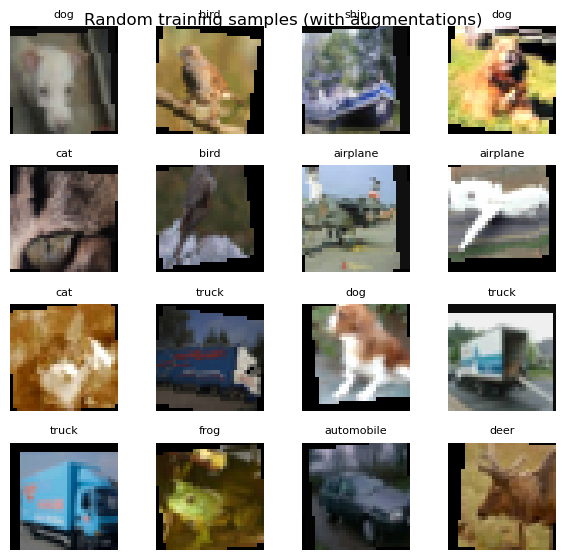

In [4]:
# Helper to unnormalize images for plotting
inv_mean = np.array([0.4914, 0.4822, 0.4465])
inv_std  = np.array([0.2023, 0.1994, 0.2010])

def unnormalize(t):
    """
    t: (C,H,W) tensor normalized with CIFAR10 stats
    returns: (H,W,C) numpy image in [0,1]
    """
    img = t.detach().cpu().numpy().transpose(1, 2, 0)
    img = img * inv_std + inv_mean
    img = np.clip(img, 0.0, 1.0)
    return img

# Show a grid of random train images
imgs, labels = next(iter(train_loader))
imgs, labels = imgs[:16], labels[:16]

fig, axes = plt.subplots(4, 4, figsize=(6, 6))
axes = axes.ravel()
for i, ax in enumerate(axes):
    ax.imshow(unnormalize(imgs[i]))
    ax.set_title(class_names[labels[i].item()], fontsize=8)
    ax.axis("off")
plt.suptitle("Random training samples (with augmentations)", y=0.92)
plt.tight_layout()
plt.show()

### Visualize augmentations of a single raw image

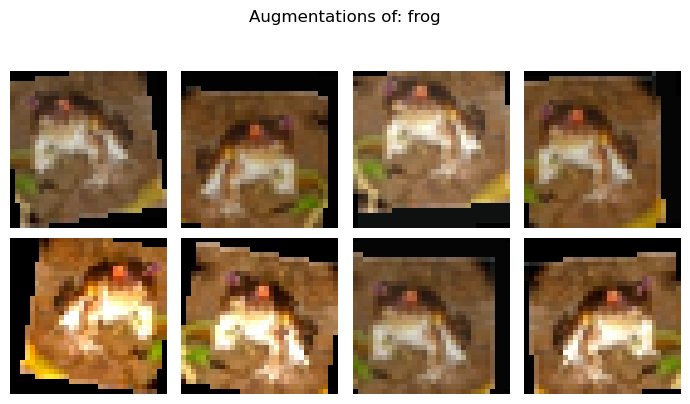

In [5]:
# Reload a raw (untransformed) dataset to show augmentations clearly
raw_train = torchvision.datasets.CIFAR10(root=DATA_ROOT, train=True, download=False, transform=None)
raw_img, raw_label = raw_train[0]

augmented = [train_transform(raw_img) for _ in range(8)]

fig, axes = plt.subplots(2, 4, figsize=(7, 4))
axes = axes.ravel()
for i, ax in enumerate(axes):
    ax.imshow(unnormalize(augmented[i]))
    ax.axis("off")
fig.suptitle(f"Augmentations of: {class_names[raw_label]}", y=1.02)
plt.tight_layout()
plt.show()

## 4. Define a CNN Model

A small but decent CIFAR-10 CNN:
- 3× Conv-BN-ReLU blocks with MaxPool
- 2× Fully connected layers
- Softmax via `CrossEntropyLoss`

In [6]:
class SmallCifarCNN(nn.Module):
    def __init__(self, num_classes: int = 10):
        super().__init__()
        self.features = nn.Sequential(
            # Block 1
            nn.Conv2d(3, 32, kernel_size=3, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 32 -> 16
            # Block 2
            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 16 -> 8
            # Block 3
            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),  # 8 -> 4
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.5),
            nn.Linear(256, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        x = self.classifier(x)
        return x

model = SmallCifarCNN(num_classes=len(class_names)).to(device)
print(model)

SmallCifarCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=2048, out_features=256, bi

## 5. Training & Validation Loop

We train with:
- Loss: CrossEntropyLoss
- Optimizer: Adam
- Metric: accuracy on train & val

We keep track of the best validation accuracy and save that model.

In [7]:
def accuracy_from_logits(logits, targets):
    preds = logits.argmax(dim=1)
    correct = (preds == targets).sum().item()
    return correct / targets.size(0)

def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss, total_acc, total_n = 0.0, 0.0, 0
    for xb, yb in loader:
        xb, yb = xb.to(device), yb.to(device)
        optimizer.zero_grad()
        logits = model(xb)
        loss = criterion(logits, yb)
        loss.backward()
        optimizer.step()

        batch_size = yb.size(0)
        total_loss += loss.item() * batch_size
        total_acc  += accuracy_from_logits(logits, yb) * batch_size
        total_n    += batch_size

    return total_loss / total_n, total_acc / total_n

def eval_one_epoch(model, loader, criterion):
    model.eval()
    total_loss, total_acc, total_n = 0.0, 0.0, 0
    with torch.no_grad():
        for xb, yb in loader:
            xb, yb = xb.to(device), yb.to(device)
            logits = model(xb)
            loss = criterion(logits, yb)
            batch_size = yb.size(0)
            total_loss += loss.item() * batch_size
            total_acc  += accuracy_from_logits(logits, yb) * batch_size
            total_n    += batch_size
    return total_loss / total_n, total_acc / total_n

In [8]:
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3, weight_decay=1e-4)

num_epochs = 20
best_val_acc = 0.0
train_hist, val_hist = [], []

os.makedirs("checkpoints", exist_ok=True)
best_ckpt_path = "checkpoints/cifar_cnn_best.pt"

for epoch in range(1, num_epochs + 1):
    train_loss, train_acc = train_one_epoch(model, train_loader, optimizer, criterion)
    val_loss,   val_acc   = eval_one_epoch(model, val_loader, criterion)

    train_hist.append((train_loss, train_acc))
    val_hist.append((val_loss, val_acc))

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), best_ckpt_path)

    print(
        f"Epoch {epoch:02d} | "
        f"Train loss={train_loss:.4f}, acc={train_acc:.4f} | "
        f"Val loss={val_loss:.4f}, acc={val_acc:.4f}"
    )

print("Best val acc:", best_val_acc)

Epoch 01 | Train loss=1.6629, acc=0.3871 | Val loss=1.4963, acc=0.4526
Epoch 02 | Train loss=1.3893, acc=0.4935 | Val loss=1.2387, acc=0.5516
Epoch 03 | Train loss=1.2678, acc=0.5438 | Val loss=1.1621, acc=0.5830
Epoch 04 | Train loss=1.1821, acc=0.5756 | Val loss=1.1060, acc=0.6110
Epoch 05 | Train loss=1.1232, acc=0.6065 | Val loss=1.0350, acc=0.6310
Epoch 06 | Train loss=1.0782, acc=0.6208 | Val loss=0.9513, acc=0.6622
Epoch 07 | Train loss=1.0326, acc=0.6386 | Val loss=0.9082, acc=0.6826
Epoch 08 | Train loss=1.0002, acc=0.6502 | Val loss=0.8699, acc=0.6874
Epoch 09 | Train loss=0.9723, acc=0.6608 | Val loss=0.8507, acc=0.6948
Epoch 10 | Train loss=0.9513, acc=0.6683 | Val loss=0.8321, acc=0.7114
Epoch 11 | Train loss=0.9237, acc=0.6777 | Val loss=0.8082, acc=0.7132
Epoch 12 | Train loss=0.9072, acc=0.6838 | Val loss=0.8139, acc=0.7078
Epoch 13 | Train loss=0.8849, acc=0.6916 | Val loss=0.8010, acc=0.7150
Epoch 14 | Train loss=0.8661, acc=0.6969 | Val loss=0.7929, acc=0.7186
Epoch 

### Plot training / validation curves

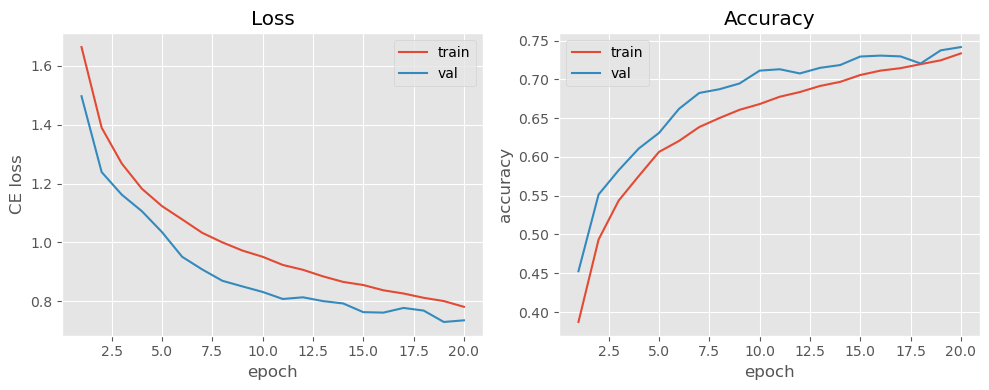

In [9]:
train_loss_arr = np.array([t[0] for t in train_hist])
train_acc_arr  = np.array([t[1] for t in train_hist])
val_loss_arr   = np.array([v[0] for v in val_hist])
val_acc_arr    = np.array([v[1] for v in val_hist])

epochs = np.arange(1, num_epochs + 1)

fig, ax = plt.subplots(1, 2, figsize=(10, 4))

ax[0].plot(epochs, train_loss_arr, label="train")
ax[0].plot(epochs, val_loss_arr, label="val")
ax[0].set_title("Loss")
ax[0].set_xlabel("epoch")
ax[0].set_ylabel("CE loss")
ax[0].legend()

ax[1].plot(epochs, train_acc_arr, label="train")
ax[1].plot(epochs, val_acc_arr, label="val")
ax[1].set_title("Accuracy")
ax[1].set_xlabel("epoch")
ax[1].set_ylabel("accuracy")
ax[1].legend()

plt.tight_layout()
plt.show()

## 6. Test Evaluation & Error Analysis

In [10]:
# Load best model before testing
best_model = SmallCifarCNN(num_classes=len(class_names)).to(device)
best_model.load_state_dict(torch.load(best_ckpt_path, map_location=device))
best_model.eval()

all_preds, all_targets = [], []

with torch.no_grad():
    for xb, yb in test_loader:
        xb, yb = xb.to(device), yb.to(device)
        logits = best_model(xb)
        preds = logits.argmax(dim=1)
        all_preds.append(preds.cpu().numpy())
        all_targets.append(yb.cpu().numpy())

all_preds    = np.concatenate(all_preds)
all_targets  = np.concatenate(all_targets)
test_acc     = (all_preds == all_targets).mean()
print("Test accuracy:", round(test_acc, 4))

/var/folders/j8/rq2yf9qs07ldt77jv70bygnh0000gn/T/ipykernel_47341/3421209796.py:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  best_model.load_state_dict(torch.load(best_ck

Test accuracy: 0.7697


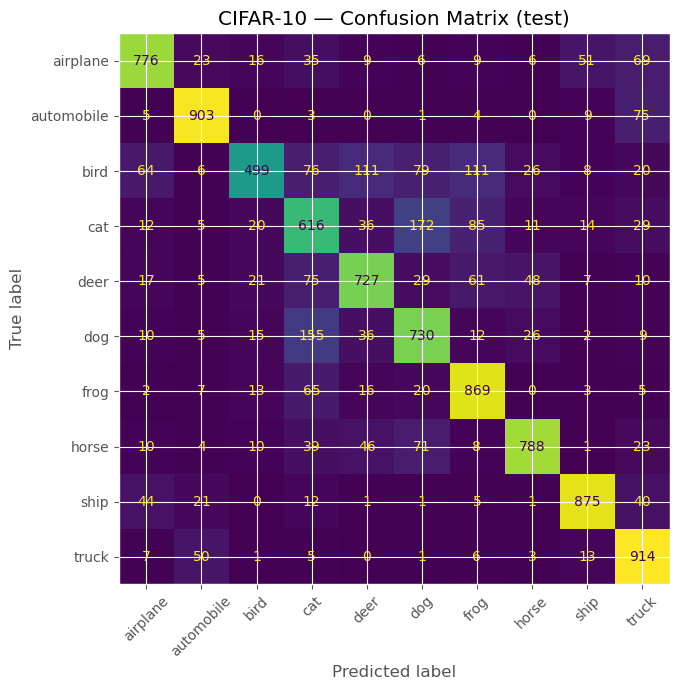

In [11]:
# Confusion matrix
cm = confusion_matrix(all_targets, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, xticks_rotation=45, colorbar=False)
plt.title("CIFAR-10 — Confusion Matrix (test)")
plt.tight_layout()
plt.show()

In [12]:
# Classification report
print(classification_report(all_targets, all_preds, target_names=class_names))

              precision    recall  f1-score   support

    airplane       0.82      0.78      0.80      1000
  automobile       0.88      0.90      0.89      1000
        bird       0.84      0.50      0.63      1000
         cat       0.57      0.62      0.59      1000
        deer       0.74      0.73      0.73      1000
         dog       0.66      0.73      0.69      1000
        frog       0.74      0.87      0.80      1000
       horse       0.87      0.79      0.83      1000
        ship       0.89      0.88      0.88      1000
       truck       0.77      0.91      0.83      1000

    accuracy                           0.77     10000
   macro avg       0.78      0.77      0.77     10000
weighted avg       0.78      0.77      0.77     10000



Total misclassified: 2303


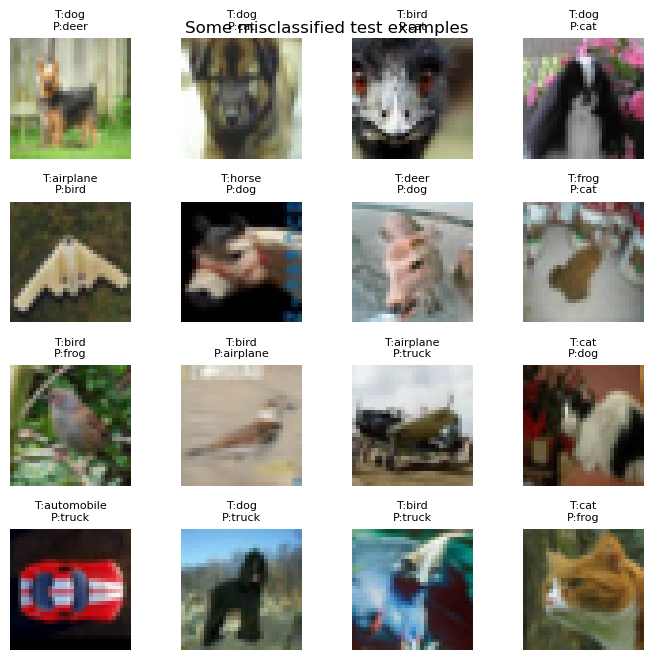

In [13]:
# Visualize some misclassified examples
wrong_idx = np.where(all_preds != all_targets)[0]
print("Total misclassified:", len(wrong_idx))

# grab up to 16
wrong_idx = wrong_idx[:16]

# reconstruct images (need to pull from test_ds, which has transform)
fig, axes = plt.subplots(4, 4, figsize=(7, 7))
axes = axes.ravel()
for ax, idx in zip(axes, wrong_idx):
    img_t, true_label = test_ds[idx]
    ax.imshow(unnormalize(img_t))
    ax.set_title(f"T:{class_names[true_label]}\nP:{class_names[all_preds[idx]]}", fontsize=8)
    ax.axis("off")
plt.suptitle("Some misclassified test examples", y=0.92)
plt.tight_layout()
plt.show()

## 7. “Deployment” — Gradio UI Interface

We now wrap the best model in a tiny web UI using `Gradio`:
- Upload an image (any RGB)  
- We resize & normalize it like CIFAR-10  
- Show top-3 class probabilities

In [14]:
# Define a model for deployment (reuse best_model)
deployed_model = best_model
deployed_model.eval()

def predict_cifar_image(img: Image.Image):
    """
    Gradio callback:
    - Takes a PIL Image
    - Resizes to 32x32 (CIFAR size)
    - Normalizes and runs through the CNN
    - Returns top-3 class probabilities
    """
    img = img.convert("RGB")
    img = img.resize((32, 32), Image.BILINEAR)

    x = inference_transform(img).unsqueeze(0).to(device)
    with torch.no_grad():
        logits = deployed_model(x)
        probs = F.softmax(logits, dim=1).cpu().numpy().ravel()

    topk = 3
    idxs = np.argsort(-probs)[:topk]
    return {class_names[i]: float(probs[i]) for i in idxs}

demo = gr.Interface(
    fn=predict_cifar_image,
    inputs=gr.Image(type="pil", label="Upload an RGB image (will be resized to 32×32)"),
    outputs=gr.Label(num_top_classes=3, label="Top-3 CIFAR-10 predictions"),
    title="CIFAR-10 CNN Classifier",
    description="Small CNN trained on CIFAR-10. Upload an image and see top-3 class probabilities.",
)

In [15]:
demo.launch(share=False)

* Running on local URL:  http://127.0.0.1:7860
* To create a public link, set `share=True` in `launch()`.


## Project Summary & Next Steps

- Built a full CIFAR-10 CNN pipeline: data → model → training → evaluation → Deployment.  
- Used data augmentation to improve generalization and robustness.  
- Performed thorough evaluation via accuracy, confusion matrix, and misclassification analysis.  
- Wrapped the trained model in a Gradio interface for lightweight interactive deployment.  

> **Next:** Proceed to `Phase 1 — Fundamentals`, covering MDPs, Bellman Equations, Dynamic Programming, Monte Carlo, and TD Learning, which form the theoretical backbone of modern Reinforcement Learning.